In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Dataset link: https://www.kaggle.com/datasets/starblasters8/human-vs-llm-text-corpus?resource=download
df = pd.read_csv("/content/drive/MyDrive/data.csv")

df.head()



,text,source,prompt_id,text_length,word_count
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380


In [ ]:
df.describe()

,prompt_id,text_length,word_count
count,788922.000000,788922.000000,788922.000000
mean,420.069514,3123.374844,497.983404
std,1381.285340,4963.074433,720.866585
min,0.000000,105.000000,25.000000
25%,0.000000,647.000000,110.000000
50%,0.000000,1921.000000,324.000000
75%,0.000000,3910.000000,624.000000
max,9913.000000,890119.000000,71543.000000


In [ ]:
df['source_binary'] = df['source'].apply(
    lambda x: 'HUMAN' if x.lower() == 'human' else 'AI'
)
df.head()

,text,source,prompt_id,text_length,word_count,source_binary
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157,AI
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778,AI
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267,AI
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848,AI
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380,AI


In [ ]:
#removing duplicates and missing values if any
df = df.dropna(subset=['text', 'source_binary'])
df = df.drop_duplicates(subset=['text'])

import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(normalize_text)

df = df[df['word_count'] >= 10].copy() # removing text with less 10 words

In [ ]:
def clean_for_tfidf(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_for_tfidf)
#df.to_csv("final.csv", index=False)

In [ ]:
print(df.shape)
print(df['source_binary'].value_counts())
print(df[['text', 'clean_text', 'word_count','text_length']].head())

(788922, 7)
source_binary
AI       441230
HUMAN    347692
Name: count, dtype: int64
                                                text  \
0  federal law supersedes state law, and cannabis...   
1  miles feels restless after working all day. he...   
2  so first of i am danish. that means that i fol...   
3  in this paper we present a novel rule-based ap...   
4  most social progressives, love democracy, and ...   

                                          clean_text  word_count  text_length  
0  federal law supersedes state law and cannabis ...         157          967  
1  miles feels restless after working all day he ...         778         5068  
2  so first of i am danish that means that i foll...         267         1602  
3  in this paper we present a novel rule based ap...         848         5469  
4  most social progressives love democracy and so...         380         2379  


In [ ]:
#segregating human and ai text rows to sample equally
df_human = df[df['source_binary'] == 'HUMAN']
df_ai = df[df['source_binary'] == 'AI']

In [ ]:
# Sample equally
df = pd.concat([
    df_human.sample(n=50000, random_state=42),
    df_ai.sample(n=50000, random_state=42)
]).reset_index(drop=True)

In [ ]:
import re
#sentence count
df['sentence_count'] = df['text'].apply(
    lambda x: len(re.findall(r'[.!?]+', x))
)

In [ ]:
import textstat
#readability feature
df['flesch'] = df['text'].apply(textstat.flesch_reading_ease)

In [ ]:
import string
#punctuation density
def punct_density(text):
    punct = sum(1 for c in text if c in string.punctuation)
    words = len(text.split())
    return punct / (words + 1)

df['punct_density'] = df['text'].apply(punct_density)

#df.to_csv("C:\\Users\\17aya\\Downloads\\dataset\\final1.csv", index=False)

In [ ]:
!python -m spacy download en_core_web_sm
!pip install scikit-learn opencv-python tqdm -q
import spacy
from tqdm.auto import tqdm

tqdm.pandas()
nlp = spacy.load("en_core_web_sm")

def pos_ratios(text):
    doc = nlp(text)
    total = len(doc)

    noun = sum(1 for token in doc if token.pos_ == 'NOUN')
    verb = sum(1 for token in doc if token.pos_ == 'VERB')
    adj  = sum(1 for token in doc if token.pos_ == 'ADJ')

    return noun/total, verb/total, adj/total

df[['noun_ratio', 'verb_ratio', 'adj_ratio']] = df['text'].progress_apply(
    lambda x: pd.Series(pos_ratios(x))
)

  0%|          | 0/99999 [00:00<?, ?it/s]

In [ ]:
df.to_csv("/content/drive/MyDrive/pos.csv", index=False)

In [ ]:
df.to_csv("final1.csv", index=False)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#loading the cleaned features csv
df = pd.read_csv("/content/drive/MyDrive/pos.csv")

df.head()

,text,source,prompt_id,text_length,word_count,source_binary,clean_text,sentence_count,flesch,punct_density,noun_ratio,verb_ratio,adj_ratio
0,i was left to help my neighbor who was pregnan...,Human,0,1570,288,0,i was left to help my neighbor who was pregnan...,14,62.797000,0.100346,0.204403,0.144654,0.081761
1,slavery history: letters analysis essay (book ...,Human,0,4163,702,0,slavery history letters analysis essay book re...,56,67.115495,0.162162,0.183115,0.112961,0.053508
2,volunteering is a part of my life that i have ...,Human,0,1338,252,0,volunteering is a part of my life that i have ...,13,66.302473,0.075099,0.154982,0.169742,0.033210
3,project risk management in the 21st century re...,Human,0,16517,2554,0,project risk management in the st century rese...,135,33.907464,0.138943,0.273883,0.108591,0.072852
4,sexual harassment in the workplace and learnin...,Human,0,14773,2279,0,sexual harassment in the workplace and learnin...,157,34.807857,0.199123,0.234977,0.091760,0.084923


In [ ]:
#df[df.isnull()].index
#df.iloc[590782]

df=df.dropna()
missing_values = df.isnull().sum()
print(missing_values)
# # Display columns with missing values
# columns_with_missing_values = missing_values[missing_values > 0].index
# print(f"Columns with missing values: {columns_with_missing_values}")

text              0
source            0
prompt_id         0
text_length       0
word_count        0
source_binary     0
clean_text        0
sentence_count    0
flesch            0
punct_density     0
dtype: int64


In [ ]:
extra_features = df[
    ['word_count', 'sentence_count', 'text_length',
     'flesch', 'punct_density'] #'noun_ratio', 'verb_ratio', 'adj_ratio']
].values

source_binary
1    331.034721
0    716.553680
Name: word_count, dtype: float64


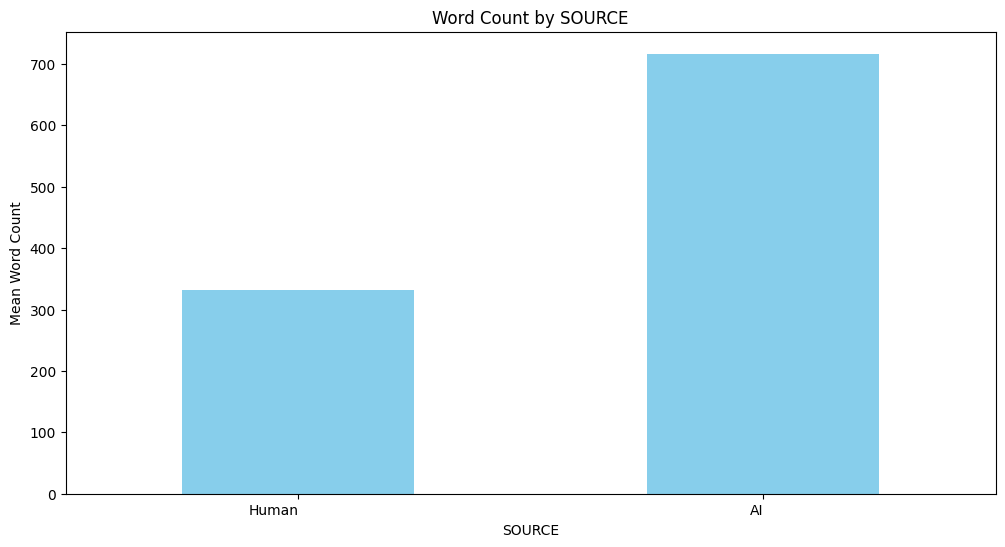

In [ ]:
mean_wordcount_by_source = df.groupby('source_binary')['word_count'].mean().sort_values()
print(mean_wordcount_by_source)
plt.figure(figsize=(12, 6))
mean_wordcount_by_source.plot(kind='bar', color='skyblue')
plt.title('Word Count by SOURCE')
plt.xlabel('SOURCE')
plt.ylabel('Mean Word Count')
plt.xticks([0, 1], ['Human', 'AI'])
plt.xticks(rotation=0, ha='right') # Rotated x-axis labels for better readability
plt.show()

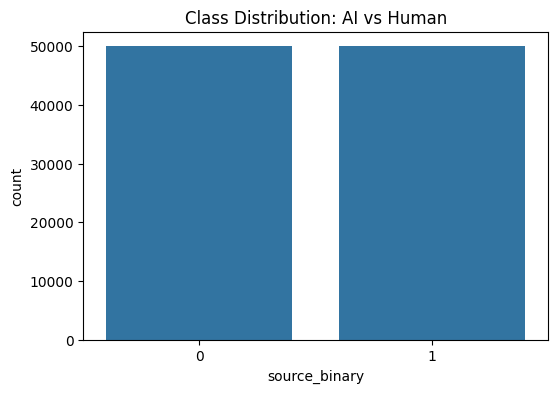

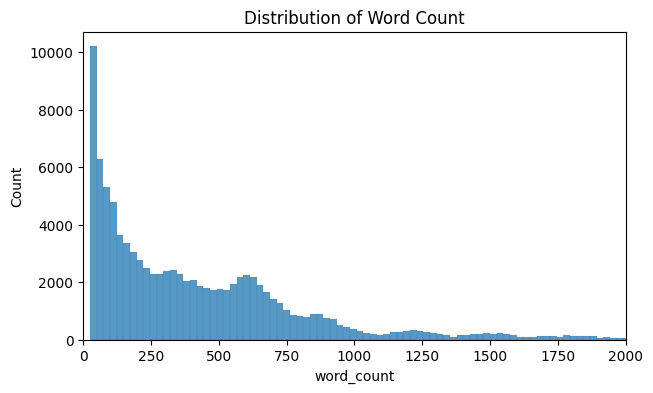

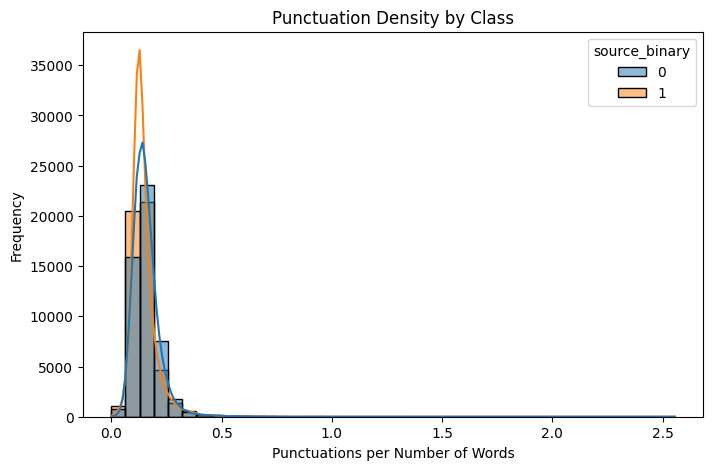

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="source_binary")
plt.title("Class Distribution: AI vs Human")
plt.show()

# WORD COUNT DISTRIBUTION
plt.figure(figsize=(7,4))
sns.histplot(df["word_count"], bins=1000)
plt.title("Distribution of Word Count")
plt.xlim(0, 2000)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='punct_density', hue='source_binary', bins=40, kde=True)
plt.title('Punctuation Density by Class')
plt.xlabel('Punctuations per Number of Words')
plt.ylabel('Frequency')
plt.show()

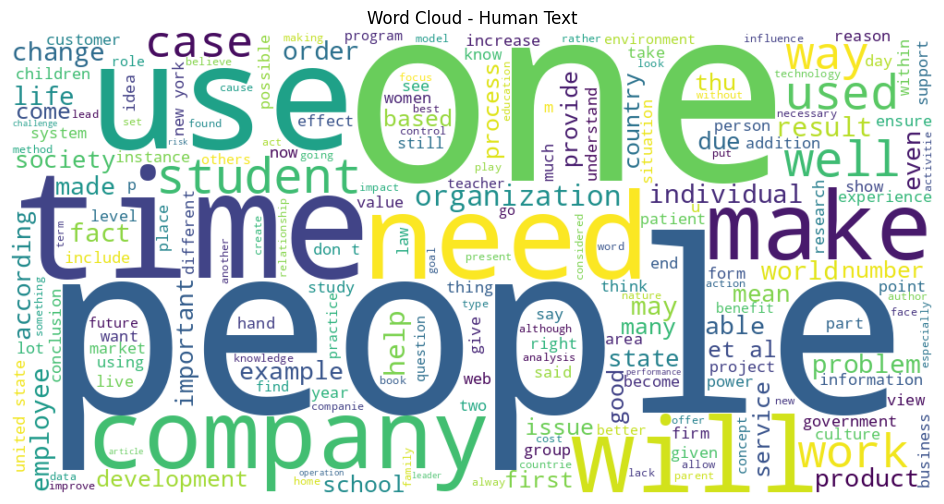

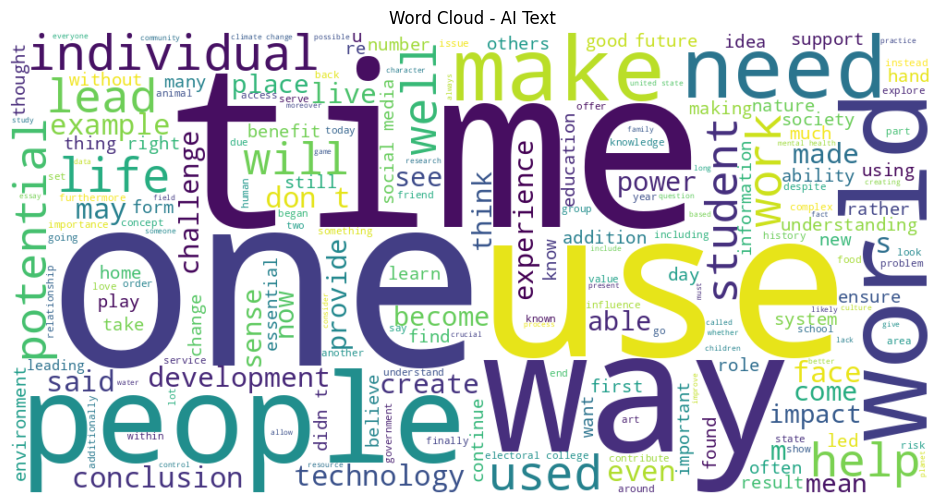

In [ ]:
from wordcloud import WordCloud
human_text = ' '.join(df[df['source_binary'] == 0]['clean_text'].astype(str))
#print(df[df['source_binary']==0])# == '0'])#['clean_text'])
wordcloud_human = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(human_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Human Text')
plt.show()

human_text = ' '.join(df[df['source_binary'] == 1]['clean_text'].astype(str))

wordcloud_human = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(human_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - AI Text')
plt.show()

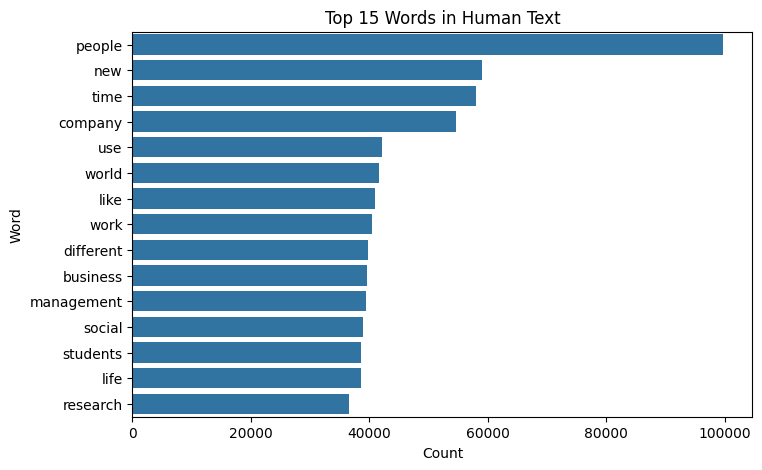

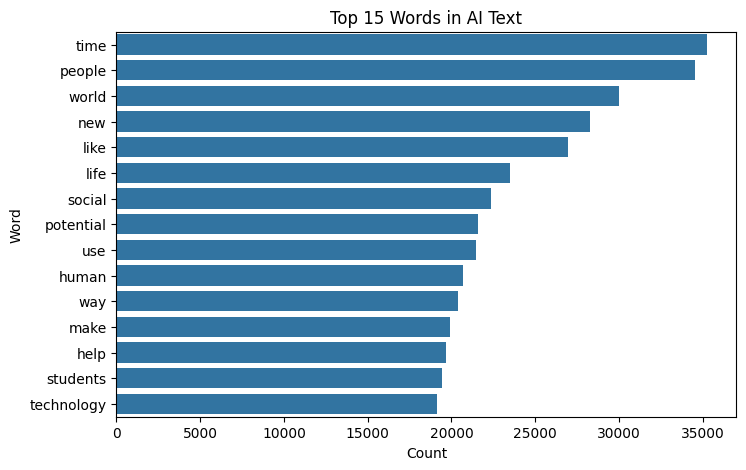

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def get_top_words(text_series, n=15):
    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(text_series)
    word_counts = np.asarray(X.sum(axis=0)).ravel()
    words = np.array(vectorizer.get_feature_names_out())

    top_idx = word_counts.argsort()[::-1][:n]
    return pd.DataFrame({
        'word': words[top_idx],
        'count': word_counts[top_idx]
    })

top_human_words = get_top_words(df[df['source_binary'] == 0]['clean_text'], n=15)
top_ai_words = get_top_words(df[df['source_binary'] == 1]['clean_text'], n=15)

# print(top_human_words)
# print(top_ai_words)

plt.figure(figsize=(8,5))
sns.barplot(data=top_human_words, x='count', y='word')
plt.title('Top 15 Words in Human Text')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=top_ai_words, x='count', y='word')
plt.title('Top 15 Words in AI Text')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

In [ ]:


corr = df[['word_count', 'sentence_count', 'text_length',
           'flesch', 'punct_density','noun_ratio', 'verb_ratio', 'adj_ratio']].corr()

print(corr)
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# sns.heatmap(corr, annot=True)
# plt.title("Feature Correlation Matrix")
# plt.show()

                word_count  sentence_count  text_length    flesch  \
word_count        1.000000        0.942807     0.979479 -0.217800   
sentence_count    0.942807        1.000000     0.936860 -0.123887   
text_length       0.979479        0.936860     1.000000 -0.241086   
flesch           -0.217800       -0.123887    -0.241086  1.000000   
punct_density     0.014649        0.135517     0.021641  0.171374   
noun_ratio        0.178655        0.117266     0.204136 -0.618352   
verb_ratio       -0.168945       -0.174191    -0.172736  0.240148   
adj_ratio         0.034064       -0.012225     0.052977 -0.438817   

                punct_density  noun_ratio  verb_ratio  adj_ratio  
word_count           0.014649    0.178655   -0.168945   0.034064  
sentence_count       0.135517    0.117266   -0.174191  -0.012225  
text_length          0.021641    0.204136   -0.172736   0.052977  
flesch               0.171374   -0.618352    0.240148  -0.438817  
punct_density        1.000000   -0.208614  

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select features
features = df[['word_count', 'sentence_count', 'text_length',
               'flesch', 'punct_density','noun_ratio', 'verb_ratio', 'adj_ratio']].copy()

# Add constant (required for VIF)
features['intercept'] = 1

# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = features.columns

vif_data['VIF'] = [
    variance_inflation_factor(features.values, i)
    for i in range(features.shape[1])
]

print(vif_data)# TEXT STATISTICS FEATURES ARE HIGHLY CORELLATED

          Feature         VIF
0      word_count   29.359650
1  sentence_count   11.500996
2     text_length   27.031347
3          flesch    1.946714
4   punct_density    1.287188
5      noun_ratio    1.793005
6      verb_ratio    1.358970
7       adj_ratio    1.392943
8       intercept  135.092313


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

In [ ]:
from sklearn.model_selection import train_test_split

#df['source_binary'] = df['source_binary'].apply(lambda x: 0 if x == 'HUMAN' else 1)
y = df['source_binary']

X_tfidf_train, X_tfidf_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_tfidf,
    y,
    df.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(max_iter=200)
y= df['source_binary']
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)



lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:

y_test_pred = lr_model.predict(X_test)
y_test_prob = lr_model.predict_proba(X_test)[:, 1]

print("\n=== TEST PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))


=== TEST PERFORMANCE ===
Accuracy: 0.8385
Precision: 0.828750981932443
Recall: 0.8502921619987911
F1 Score: 0.8393833913475882
ROC-AUC: 0.9220592019618995


In [ ]:
from xgboost import XGBClassifier

def modelTrain(X_train, y_train):

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
)

    model.fit(X_train, y_train)
    modelPredict(X_train,X_test, y_test, model)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def modelPredict(X_train,X_test, y_test,model):
    # y_pred = model.predict(X_test)
    # y_prob = model.predict_proba(X_test)[:, 1]

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

    print("TRAIN PERFORMANCE")
    print("Accuracy:", accuracy_score(y_train, y_train_pred))
    print("F1:", f1_score(y_train, y_train_pred))
    print("Recall:", recall_score(y_train, y_train_pred))
    print("ROC-AUC:", roc_auc_score(y_train, y_train_prob))

    print("\nTEST PERFORMANCE")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1:", f1_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

    # print("Accuracy:", accuracy_score(y_test, y_pred))
    # print("Precision:", precision_score(y_test, y_pred))
    # print("Recall:", recall_score(y_test, y_pred))
    # print("F1-score:", f1_score(y_test, y_pred))
    # print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
######### MODEL 1 - ONLY TFIDF #################
X_train = X_tfidf_train
X_test = X_tfidf_test

modelTrain(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:10:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


TRAIN PERFORMANCE
Accuracy: 0.6816085201065013
F1: 0.6829638665189629
Recall: 0.6846255583560003
ROC-AUC: 0.7751563832188193

TEST PERFORMANCE
Accuracy: 0.4931
F1: 0.4971230158730159
Recall: 0.5048357848075761
ROC-AUC: 0.48724298142566286


In [ ]:
############# Model 2 - Text Statistics feature #####################
from sklearn.model_selection import train_test_split

X=df[['word_count']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)


TRAIN PERFORMANCE
Accuracy: 0.6374829685371067
F1: 0.6911271340781527
Recall: 0.8096723479649639
ROC-AUC: 0.6976385394906063

TEST PERFORMANCE
Accuracy: 0.6285
F1: 0.6823971958621868
Recall: 0.8041507152931695
ROC-AUC: 0.6903752399481395


In [ ]:
############# Model 3 - Text Statistics + readability features + PUNCTUATION #####################

X=df[['word_count','flesch','punct_density']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

TRAIN PERFORMANCE
Accuracy: 0.7255840698008725
F1: 0.7308592935868672
Recall: 0.7438175330022708
ROC-AUC: 0.8183490032384031

TEST PERFORMANCE
Accuracy: 0.71375
F1: 0.7182162720874145
Recall: 0.7350392907515616
ROC-AUC: 0.8072080477126928


In [ ]:
############# Model 4 - Text Statistics + TFIDF features #####################

import scipy.sparse as sp
X_numeric = df[['word_count']].values

# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:14:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


TRAIN PERFORMANCE
Accuracy: 0.8802735034187927
F1: 0.8834254278133443
Recall: 0.9056471938711851
ROC-AUC: 0.9587412307933503

TEST PERFORMANCE
Accuracy: 0.8617
F1: 0.8644383454224662
Recall: 0.888474712875277
ROC-AUC: 0.9452351110746825


In [ ]:
############# Model 5 - Text Statistics + readability + tfidf features #####################

import scipy.sparse as sp
X_numeric = df[[ 'word_count','flesch']].values

# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:31:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


TRAIN PERFORMANCE
Accuracy: 0.8750859385742322
F1: 0.8806164506301893
Recall: 0.9197215082474484
ROC-AUC: 0.9558942759449478

TEST PERFORMANCE
Accuracy: 0.85185
F1: 0.857719087635054
Recall: 0.8997582107596211
ROC-AUC: 0.9402638738497321


In [ ]:
############# Model 6 - Text Statistics + readability + PUNCTUATION + TFIDF features #####################

import scipy.sparse as sp
X_numeric = df[['word_count','flesch','punct_density']].values
y=df['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

TRAIN PERFORMANCE
Accuracy: 0.8746234327929099
F1: 0.8804215646534252
Recall: 0.9214184113991964
ROC-AUC: 0.9558724153246254

TEST PERFORMANCE
Accuracy: 0.85315
F1: 0.8588862730024504
Recall: 0.9004634293773927
ROC-AUC: 0.940496691598832


In [ ]:
##################### MODEL 7 - ALL FEATURES COMBINED WITH POS TAGGING ################
import scipy.sparse as sp
X_numeric = df[['word_count','flesch','punct_density','noun_ratio', 'verb_ratio', 'adj_ratio']].values
y= df['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

TRAIN PERFORMANCE
Accuracy: 0.7596219952749409
F1: 0.7640085413445254
Recall: 0.7767823721707883
ROC-AUC: 0.8532259882289485

TEST PERFORMANCE
Accuracy: 0.74245
F1: 0.7454410674573758
Recall: 0.7598226878903889
ROC-AUC: 0.8338459014015608


In [ ]:
##################### MODEL 7 - ALL FEATURES COMBINED WITH POS TAGGING + TFIDF ################
import scipy.sparse as sp
X_numeric = df[['word_count','flesch','punct_density','noun_ratio', 'verb_ratio', 'adj_ratio']].values
y= df['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

TRAIN PERFORMANCE
Accuracy: 0.8760609507618845
F1: 0.8817291520045806
Recall: 0.9222918174331844
ROC-AUC: 0.9569855134726766

TEST PERFORMANCE
Accuracy: 0.8544
F1: 0.8604294478527608
Recall: 0.9042917590167238
ROC-AUC: 0.9410515319818913


ValueError: The number of FixedLocator locations (15), usually from a call to set_ticks, does not match the number of labels (5004).

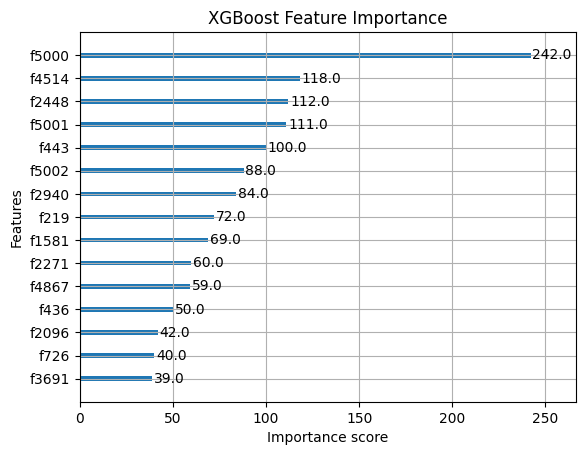

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
)

model.fit(X_train, y_train)
feature_names = list(tfidf.get_feature_names_out()) + [
    "word_count", "avg_sentence_length", "flesch", "punct_density"
]
plot_importance(model, max_num_features=15)
plt.title("XGBoost Feature Importance")
# Replace y-tick labels
ax = plt.gca()
ax.set_yticklabels(feature_names[::-1])
plt.show()




In [ ]:
##################### MODEL 8 -  WITH POS TAGGING ################
import scipy.sparse as sp
X_numeric = df[['noun_ratio', 'verb_ratio', 'adj_ratio']].values
y= df['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
#X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

TRAIN PERFORMANCE
Accuracy: 0.6680708508856361
F1: 0.6521249279463397
Recall: 0.6210915079979038
ROC-AUC: 0.729243913520101

TEST PERFORMANCE
Accuracy: 0.6476
F1: 0.6289354533010424
Recall: 0.6017529719927464
ROC-AUC: 0.697877775787002


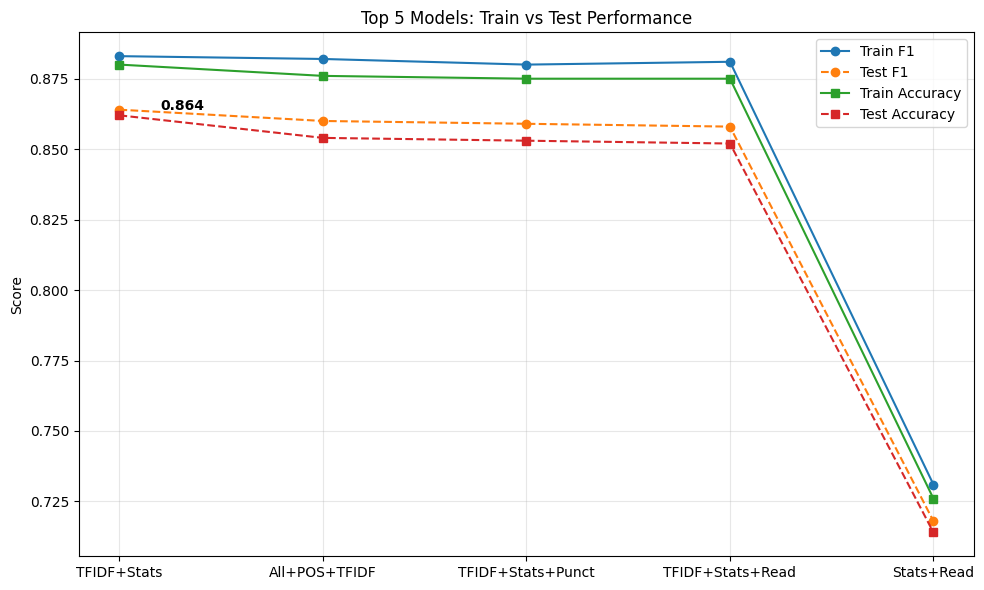

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models_top5 = [
    "TFIDF+Stats",
    "All+POS+TFIDF",
    "TFIDF+Stats+Punct",
    "TFIDF+Stats+Read",
    "Stats+Read"
]

train_f1 = [0.883, 0.882, 0.880, 0.881, 0.731]
test_f1  = [0.864, 0.860, 0.859, 0.858, 0.718]

train_acc = [0.880, 0.876, 0.875, 0.875, 0.726]
test_acc  = [0.862, 0.854, 0.853, 0.852, 0.714]

x = np.arange(len(models_top5))

plt.figure(figsize=(10,6))

plt.plot(x, train_f1, marker='o', label="Train F1")
plt.plot(x, test_f1, marker='o', linestyle='--', label="Test F1")

plt.plot(x, train_acc, marker='s', label="Train Accuracy")
plt.plot(x, test_acc, marker='s', linestyle='--', label="Test Accuracy")

plt.xticks(x, models_top5)
plt.ylabel("Score")
plt.title("Top 5 Models: Train vs Test Performance")

# Highlight best model
best_idx = np.argmax(test_f1)
plt.text(best_idx + 0.2, test_f1[best_idx],
         f"{test_f1[best_idx]:.3f}",
         fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "LogReg (TF-IDF)",
    "XGB (Stats)",
    "XGB (Stats+Read)",
    "XGB (TF-IDF)",
    "XGB (TFIDF+Stats)",
    "XGB (POS)",
    "XGB (All+POS+TFIDF)"
]

# F1 scores
f1_scores = [
    0.49,
    0.50,
    0.68,
    0.72,
    0.864,
    0.745,
    0.860
]

# plt.figure(figsize=(10,6))
# plt.barh(models, f1_scores)

# plt.xlabel("F1 Score")
# plt.title("Model Comparison (F1 Score)")
# plt.xlim(0, 1)

# plt.tight_layout()
# plt.show()

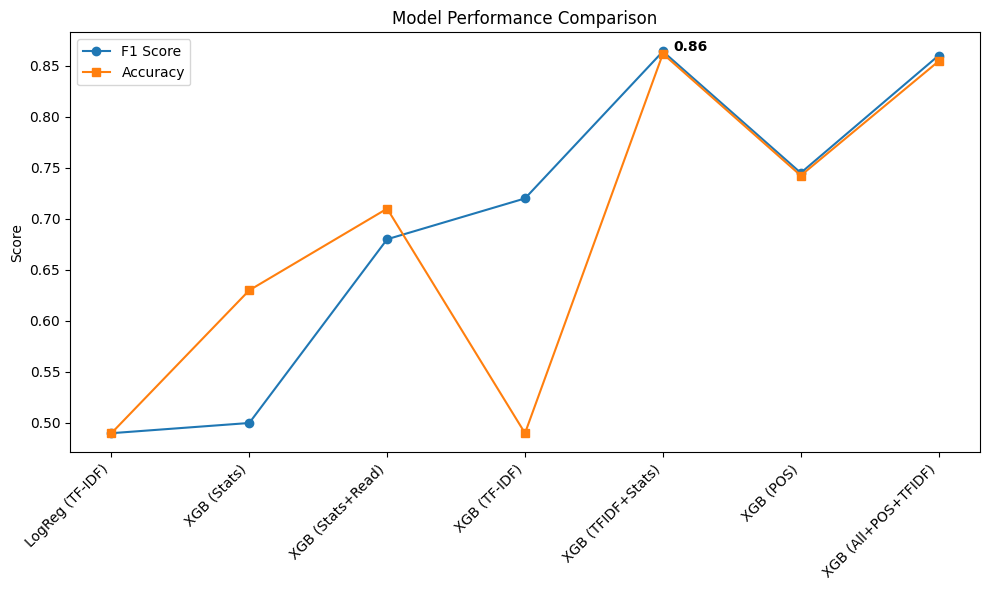

In [ ]:
accuracy = [
    0.49,
     0.63,
    0.71,
    0.49,


    0.8617,
    0.7424,
    0.8544
]
f1_arr = np.array(f1_scores)
acc_arr = np.array(accuracy)

# Find max indices
max_f1_idx = np.argmax(f1_arr)
max_acc_idx = np.argmax(acc_arr)
plt.figure(figsize=(10,6))

x = range(len(models))

plt.plot(x, f1_scores, marker='o', label="F1 Score")
plt.plot(x, accuracy, marker='s', label="Accuracy")

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Model Performance Comparison")
# 🔥 Annotate max F1
plt.text(max_f1_idx +0.2, f1_arr[max_f1_idx],
         f"{f1_arr[max_f1_idx]:.2f}",
         ha='center', fontweight='bold')

# # 🔥 Annotate max Accuracy
# plt.text(max_acc_idx - 0.2, acc_arr[max_acc_idx] ,
#          f"{acc_arr[max_acc_idx]:.2f}",
#          ha='right', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

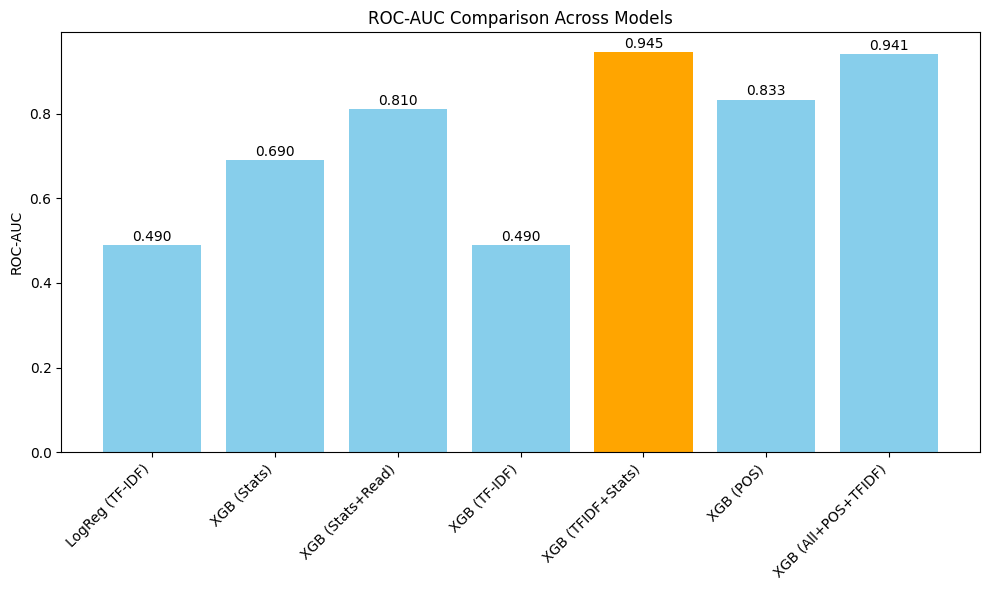

In [ ]:


import matplotlib.pyplot as plt
import numpy as np

roc_auc = [
    0.49,
    0.69,
    0.81,
    0.49,


    0.945,
    0.833,
    0.941
]

# Find index of max value
max_idx = np.argmax(roc_auc)

# Create color list
colors = ['skyblue'] * len(roc_auc)
colors[max_idx] = 'orange'   # highlight max

plt.figure(figsize=(10,6))
bars = plt.bar(models, roc_auc, color=colors)

plt.xticks(rotation=45, ha='right')
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison Across Models")

# Optional: add value labels
for i, v in enumerate(roc_auc):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()